In [64]:
import openai
import json
openai.api_base = "https://openai.vocareum.com/v1"
openai.api_key = 'voc-339584629126677370129467859253d08721.55430420'
import os 
os.environ["OPENAI_API_BASE"] = "https://openai.vocareum.com/v1"
os.environ['OPENAI_API_KEY']= 'voc-339584629126677370129467859253d08721.55430420'
import lancedb
from openai import OpenAI
client = OpenAI(
    base_url = "https://openai.vocareum.com/v1",
    api_key ='voc-339584629126677370129467859253d08721.55430420'
)
from pydantic import BaseModel, Field







In [65]:
def stringifyHome(s:pd.Series | dict):
    home_str = f"""
ID : {int(s['id'])}
Neighborhood : {s['neighborhood']}
Price : {s['home_price']}
Bedrooms : {s['n_bedrooms']}
Bathrooms : {s['n_bathrooms']}
House Size : {s['house_size_sqft']}
Lot Size : {s['lot_size_sqft']}
Home Type : {s['home_type']}
Home Description : {s['home_description']}
Neighborhood Description : {s['neighborhood_description']}
    """
    return home_str

exampleOutput = """
Neighborhood: Green Oaks
Price: $800,000
Bedrooms: 3
Bathrooms: 2
House Size: 2,000 sqft

Description: Welcome to this eco-friendly oasis nestled in the heart of Green Oaks. This charming 3-bedroom, 2-bathroom home boasts energy-efficient features such as solar panels and a well-insulated structure. Natural light floods the living spaces, highlighting the beautiful hardwood floors and eco-conscious finishes. The open-concept kitchen and dining area lead to a spacious backyard with a vegetable garden, perfect for the eco-conscious family. Embrace sustainable living without compromising on style in this Green Oaks gem.

Neighborhood Description: Green Oaks is a close-knit, environmentally-conscious community with access to organic grocery stores, community gardens, and bike paths. Take a stroll through the nearby Green Oaks Park or grab a cup of coffee at the cozy Green Bean Cafe. With easy access to public transportation and bike lanes, commuting is a breeze." \
"""
print(exampleOutput)


Neighborhood: Green Oaks
Price: $800,000
Bedrooms: 3
Bathrooms: 2
House Size: 2,000 sqft

Description: Welcome to this eco-friendly oasis nestled in the heart of Green Oaks. This charming 3-bedroom, 2-bathroom home boasts energy-efficient features such as solar panels and a well-insulated structure. Natural light floods the living spaces, highlighting the beautiful hardwood floors and eco-conscious finishes. The open-concept kitchen and dining area lead to a spacious backyard with a vegetable garden, perfect for the eco-conscious family. Embrace sustainable living without compromising on style in this Green Oaks gem.

Neighborhood Description: Green Oaks is a close-knit, environmentally-conscious community with access to organic grocery stores, community gardens, and bike paths. Take a stroll through the nearby Green Oaks Park or grab a cup of coffee at the cozy Green Bean Cafe. With easy access to public transportation and bike lanes, commuting is a breeze." 


## Set up DB and Schema 

In [66]:
from lancedb.pydantic import vector , LanceModel
import pyarrow as pa 
import numpy as np 
import pandas as pd 

table_name = 'homes'
db = lancedb.connect('./homematchdb')


class homeSchema(LanceModel):
    id : int
    neighborhood: str
    home_price: int
    n_bedrooms: int 
    n_bathrooms: float
    house_size_sqft: int
    lot_size_sqft: int 
    home_type: str 
    home_description: str 
    home_description_embed: vector(1536)
    neighborhood_description: str
    neighborhood_description_embed: vector(1536)
    

    

In [67]:
import json
def generate_house_listing():
    response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
            {
              "role": "system",
              "content": """ you are a real estate brokerage in Washington State that has a list of homes.  Make sure to report on a list of homes in the following Json format:

  Neighborhood: [Neighborhood]
  Price: [integer price]
  Bedrooms: [integer number of bedrooms]
  Bathrooms: [integer number of bathrooms]
  House Size: [integer total square feet of home]
  Lot Size: [integer total square feet of lot]
  Home Type: [ENUM one of Condominium, Townhome, House, MultiFamily]

  Description: [a description of the home - without any new lines kept in a single large paragraph]

  Neighborhood Description: [a description of the neighborhood  the home is in - without any new lines kept in a single large paragraph]
          
                """
            },
            {
              "role": "user",
              "content": "Give me one of the homes in your inventory"
            }
            ],
          temperature=1,
          max_tokens=512,
          top_p=1,
          frequency_penalty=0,
          presence_penalty=0,
          response_format={"type": 'json_object'}
          )
          # The response is a JSON object containing more information than the response. We want to return only the message content
  
    return json.loads(response.choices[0].message.content)

In [68]:
import tqdm 






In [69]:
def prepareListingsUpload(n_listings:int, index_start=0, ):
    listings = [ generate_house_listing() for _ in tqdm.tqdm(range(n_listings))]
    house_emb = client.embeddings.create(input=[d['Description'] for  d in listings],model='text-embedding-3-small')
    neighborhood_emb = client.embeddings.create(input=[d['Description'] for  d in listings],model='text-embedding-3-small')
    house_emb_array = [np.array(e.embedding) for e in house_emb.data]
    neighborhood_emb_array = [np.array(e.embedding) for e in neighborhood_emb.data]
    listings_df = pd.DataFrame(listings)
    
    values = list(zip(listings_df.index + index_start + 1,
                    listings_df['Neighborhood'],
                    listings_df['Price'],
                    listings_df['Bedrooms'],
                    listings_df['Bathrooms'],
                    listings_df['House Size'],
                    listings_df['Lot Size'],
                    listings_df['Home Type'],
                    listings_df['Description'],
                    house_emb_array,
                    listings_df['Neighborhood Description'],
                    neighborhood_emb_array
                    ))
    keys = homeSchema.__annotations__.keys()
    data = [dict(zip(keys, v)) for v in values]

    return data



In [70]:






# # data[0]
# listings_df = pd.DataFrame(listings)
# print(listings_df.columns)


In [71]:

RESET = False 
OVERWRITE = False

if table_name in db.table_names() and RESET:
    db.drop_table(table_name)    
    table = db.create_table('homes', schema=homeSchema)
elif table_name in db.table_names() and OVERWRITE:
    table = db[table_name]
    arrow_data = table.to_arrow()
    table = db.create_table('homes', arrow_data, schema=homeSchema, mode='overwrite') 
elif table_name in db.table_names() :
    print("table exists ... ")
    table = db[table_name]   
else:
    table = db.create_table('homes', schema=homeSchema)

table exists ... 


In [72]:
if table.count_rows() > 0:
    start_index=int(table.to_arrow()['id'].to_numpy().max())
    start_index
else:
    start_index = 0

# ## UNCOMMENT FOR UPLOADING NEW DATA    
# data = prepareListingsUpload(40, start_index)
# print(f"Uploading {len(data)} rows")
# table.add(data)


## Using Langchain 

In [146]:

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage , ToolCall, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from langchain.chat_models import init_chat_model

import os

## Building Tools 

In [74]:
from langchain_core.tools import tool,ArgsSchema


def extractNeighborhoodPreferences(buyerPreferences:str):
  response = client.chat.completions.create(
              model="gpt-3.5-turbo",
              messages=[
              {
                "role": "system",
                "content": 
      """ 
      You are an experienced real estate agent that is involved in interpolating the neighborhood requirements.  Given a description extract all features of a neighborhood the buyer is looking for into a paragraph. 

      Remember this is only for the neighborhood, we have another expert looking for the actual home requriments.  You will solely focus on the neighborhood preferences.

      If there is no buyer preferences in regards to neighborhood simply return "None"
      """
              },
              {
                "role": "user",
                "content": f"Interpolate my neighborhood requirements: {buyerPreferences}"
              }
              ],
            temperature=0.01,
            max_tokens=512,
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
            # response_format={"type": 'json_object'}
            )
            # The response is a JSON object containing more information than the response. We want to return only the message content
    
  return response.choices[0].message.content    

from typing import List 
def ProfileSummarizerAgent(messages):    
    
    response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
            {
              "role": "system",
              "content": 
    """ 
    You are personalization assistant. Your job is to intake the conversation between the user and Real Estate Agent and summarize what the user is looking for 
    """
            }
            ] + 
            messages 
            + [
            {
              "role": "user",
              "content": "Summarize the request based on the discussion in to a new paragraph with the latest preferences established"
            }
            ],
          temperature=0.01,
          max_tokens=512,
          top_p=1,
          frequency_penalty=0,
          presence_penalty=0,
          # response_format={"type": 'json_object'}
          )
          # The response is a JSON object containing more information than the response. We want to return only the message content
  
    return response.choices[0].message.content




#### List Filter Construction:

In [75]:

def listingFilterSearchAgent(prompt):
    response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
            {
              "role": "system",
              "content": 
    """ 
    You are a query agent responsible for providing SQL filters on the following fields based on a prompt.
    given a description by what the user is looking for you will return which fields below are relevant 
    and will generate the clauses needed.  Also keep track of any homes specifically the buyer did or  didn't like by the ids provided

    id: int
    home_price: int 
    n_bedrooms: int     
    n_bathrooms: int
    house_size_sqft: int
    lot_size_sqft: int 
    home_type: ENUM["Townhome", "House", "Condominium", "MultiFamily"] 
    
    For instance, if the user says: "Looking for a home thats less than $800,000 and has exactly 2 bathrooms but no more than 5 bedrooms" you would output the following json:

    {sql_filter : "home_price < 800000 and n_bedrooms = 2 and bedrooms <= 5"}

    """
            },
            {
              "role": "user",
              "content": prompt
            }
            ],
          temperature=0.01,
          max_tokens=512,
          top_p=1,
          frequency_penalty=0,
          presence_penalty=0,
          response_format={"type": 'json_object'}
          )
          # The response is a JSON object containing more information than the response. We want to return only the message content
    r = response.choices[0].message.content
    return json.loads(r)['sql_filter']



#### RealEstatePersonalizer


In [76]:

class RealEstatePersonalizerInput(BaseModel):
   homes: str = Field(description="Concatenated List of homes and their descriptions and specifications. This will be in order of what we think align best with the preferences the buyer was looking for.")
   preferences:str = Field(description="this is a summary of all the preferences the buy was looking for throughout the discussion.")

# @tool(args_schema=RealEstatePersonalizerInput)
def RealEstatePersonalizer(homes:str, preferences:str):
    """Personalizes a description of a property based on the preferences.
    
    Args: 
      homes (str) - Concatenated List of homes and their descriptions and specifications. This will be in order of what we think align best with the preferences the buyer was looking for .
      preferences (str): this is a summary of all the preferences the buy was looking for throughout the discussion.

    Returns:
      str: the same list of homes but with an excerpt at the bottom of each of why we think that home best suits their needs and why its a great home for them based on their preferences
    """


    llm_prephomes = init_chat_model("gpt-3.5-turbo", model_provider="openai")
    prephome_prompt = ChatPromptTemplate.from_messages(
        [
            SystemMessage(
                content= f""" 
      You are an experienced real estate agent that understands the buyers preferences very well.
      Given a list of homes and preferences you will respond with a reason for why EACH home works with the buyers preferences.
      Make sure to always include the listing ID in parenthesis when referencing the houses so you can refer back to them later and explain at the bottom 
      """
            ),
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    messages = [HumanMessage(content = f"Here are my preferences: {preferences} \n\n Here's a list My agent found for me {homes}")]
    
    chain = prephome_prompt | llm_prephomes

    return chain.invoke({"messages" : messages}).content

    # response = client.chat.completions.create(
    #           model="gpt-3.5-turbo",
    #           messages=[
    #           {
    #             "role": "system",
    #             "content": 
    #   f""" 
    #   You are an experienced real estate agent that understands the buyers preferences very well.
    #   Given a list of homes and preferences you will respond with a reason for why EACH home works with the buyers preferences.
    #   Make sure to always include the listing ID in parenthesis when referencing the houses so you can refer back to them later and explain at the bottom 
    #   """
    #           },
    #           {
    #             "role": "user",
    #             "content": f"Here are my preferences: {preferences} \n\n Here's a list My agent found for me {'\n'.join(homes)}"
    #           }
    #           ],
    #         temperature=0.01,
    #         max_tokens=512,
    #         top_p=1,
    #         frequency_penalty=0,
    #         presence_penalty=0,
    #         # response_format={"type": 'json_object'}
    #         )
    #         # The response is a JSON object containing more information than the response. We want to return only the message content
    
    # return response.choices[0].message.content    


##### Search Homes Tool

In [101]:
e = client.embeddings.create(input="Disregard any craftsman",model='text-embedding-3-small').data[0].embedding
table.search(e,vector_column_name='home_description_embed').metric('cosine').limit(10).to_pandas()

,id,neighborhood,home_price,n_bedrooms,n_bathrooms,house_size_sqft,lot_size_sqft,home_type,home_description,home_description_embed,neighborhood_description,neighborhood_description_embed,_distance
0,79,Capitol Hill,850000,3,2.0,1800,5000,House,Beautiful Craftsman style home with updated ki...,"[0.005536993, -0.0028218909, 0.0017179629, -0....",Capitol Hill is a vibrant neighborhood known f...,"[0.005517378, -0.002820112, 0.001729188, -0.00...",0.705724
1,67,Ballard,850000,3,2.0,1800,4000,House,Beautiful craftsman home in the heart of Balla...,"[-0.0057323393, -0.037109066, 0.045375064, 0.0...",Ballard is a vibrant neighborhood known for it...,"[-0.005689939, -0.03711929, 0.045387574, 0.017...",0.714941
2,1,Greenwood,750000,3,2.0,1800,4000,House,Beautifully updated Craftsman home in the hear...,"[0.02297153, 0.004972461, 0.04598821, 0.028649...",Greenwood is a vibrant and eclectic neighborho...,"[0.02297153, 0.004972461, 0.04598821, 0.028649...",0.716935
3,11,Capitol Hill,750000,3,2.0,1800,5000,House,Beautifully renovated Craftsman home in the he...,"[0.02297153, 0.004972461, 0.04598821, 0.028649...",Capitol Hill is a vibrant and diverse neighbor...,"[0.02297153, 0.004972461, 0.04598821, 0.028649...",0.716935
4,5,Greenwood,675000,3,2.0,1800,5000,House,Beautifully renovated Craftsman home in the he...,"[0.021688491, -0.003011699, 0.050571006, 0.014...",Greenwood is a vibrant neighborhood known for ...,"[0.021688491, -0.003011699, 0.050571006, 0.014...",0.718961
5,15,Capitol Hill,850000,2,2.0,1300,0,Condominium,Beautiful modern condominium in the heart of C...,"[0.021688491, -0.003011699, 0.050571006, 0.014...",Capitol Hill is known for its eclectic mix of ...,"[0.021688491, -0.003011699, 0.050571006, 0.014...",0.718961
6,26,Green Lake,850000,3,2.0,1800,4000,House,Beautiful craftsman style home located in the ...,"[0.016669191, -0.017996194, 0.066758424, 0.022...",Green Lake is known for its vibrant community ...,"[0.016669191, -0.017996194, 0.066758424, 0.022...",0.719280
7,90,Greenwood,650000,3,2.0,1800,4000,House,Beautifully updated craftsman home in the hear...,"[0.021919752, -0.00491968, 0.04256847, 0.00966...",Greenwood is a vibrant neighborhood known for ...,"[0.02195843, -0.0049292156, 0.042600915, 0.009...",0.723037
8,8,Capitol Hill,950000,3,2.0,1800,2500,House,Stunning Craftsman home located in the heart o...,"[0.02837034, -0.029797506, 0.041582443, 0.0295...",Capitol Hill is a vibrant neighborhood known f...,"[0.02839005, -0.029817121, 0.041579638, 0.0295...",0.726019
9,18,Ballard,750000,3,2.0,1800,2500,House,This beautiful home in Ballard features 3 bedr...,"[0.02837034, -0.029797506, 0.041582443, 0.0295...",Ballard is a trendy neighborhood known for its...,"[0.02839005, -0.029817121, 0.041579638, 0.0295...",0.726019


In [102]:
class searchHomesInput(BaseModel):
   buyerHomePreferences:str = Field(description="the summary of buyer home preferences that have been discussed that outlines all the requirements by the buyer.")
   limit: int = Field(description="the number of homes to return.", default=3)

@tool(args_schema=searchHomesInput, return_direct=True)
def searchHomes(buyerHomePreferences:str, limit:int=3):
    """Retrieves all the homes provided a paragraph of all the preferences the buyer is looking for.capitalize

    Args:
      buyerHomePreferences (str): the summary of buyer home preferences that have been discussed that outlines all the requirements by the buyer.
      limit (int): the number of homes to return.

    Returns:
      str: a concatenated list of all the details of a home separated by "\n\n"
    """
    e = client.embeddings.create(input=buyerHomePreferences,model='text-embedding-3-small').data[0].embedding
    neighborhoodPreferences = extractNeighborhoodPreferences(buyerHomePreferences)
    
    filters = listingFilterSearchAgent(buyerHomePreferences)
    if not 'none' in neighborhoodPreferences.lower(): 
      neighborhood_e = client.embeddings.create(input=neighborhoodPreferences,model='text-embedding-3-small').data[0].embedding
      neighborhood_results = table.search(e,vector_column_name='neighborhood_description_embed').metric('cosine').where(filters) 
      neighborhood_results = neighborhood_results.to_pandas()
    else:
      neighborhood_results = pd.DataFrame()

    lance_results = table.search(e,vector_column_name='home_description_embed').metric('cosine').where(filters)

    result_set =  pd.concat((lance_results.to_pandas().assign(source='home_desc')
                             ,neighborhood_results.assign(source='neighborhood_desc')),axis=0).sort_values('_distance', ascending=True)
    if result_set.shape[0] > 0 :
       return '\n\n'.join([stringifyHome(x) for i,x in result_set.drop_duplicates(subset='id').head(limit).iterrows()])
    else:
       return "No examples found"
    


 


In [103]:
r = searchHomes("I hate craftsman style homes")
# r.to_pandas()

print(r)



ID : 79
Neighborhood : Capitol Hill
Price : 850000.0
Bedrooms : 3.0
Bathrooms : 2.0
House Size : 1800.0
Lot Size : 5000.0
Home Type : House
Home Description : Beautiful Craftsman style home with updated kitchen, hardwood floors, and a spacious backyard perfect for entertaining. The home features a cozy fireplace in the living room, a master suite with a walk-in closet, and a detached garage. Located within walking distance to trendy shops, restaurants, and parks.
Neighborhood Description : Capitol Hill is a vibrant neighborhood known for its historic homes, eclectic shops, and thriving coffee culture. Residents enjoy easy access to public transportation and are just a short drive away from downtown Seattle. The neighborhood has a strong sense of community and is popular among young professionals and families alike.
    


ID : 81
Neighborhood : Capitol Hill
Price : 750000.0
Bedrooms : 2.0
Bathrooms : 1.0
House Size : 1200.0
Lot Size : 1500.0
Home Type : House
Home Description : Beauti

In [104]:
print(RealEstatePersonalizer(r,"Looking for home in Greenwood"))



Each of the homes in Capitol Hill could be a great fit for you because this neighborhood offers a vibrant atmosphere with trendy shops, restaurants, and parks, making it an attractive location for both young professionals and families. Additionally, Capitol Hill is known for its historic homes and strong sense of community, providing a welcoming environment for residents.

- Home (79) has 3 bedrooms and 2 bathrooms, providing ample space for a family or guests. The updated kitchen and spacious backyard make it perfect for entertaining, and the detached garage offers convenience for parking.
  
- Home (81) with 2 bedrooms and 1 bathroom still provides a cozy living space with a charming atmosphere. The recently updated kitchen and spacious backyard also offer a great entertaining space.

- Lastly, Home (8) offers a stunning Craftsman home with an open concept living space, modern kitchen, and a spacious master suite, ideal for those seeking a more luxurious living experience within the 

In [120]:
from typing import Union, Any
class RealEstateAgentMessage(HumanMessage):
    def __init__(self, content: Union[str, list[Union[str, dict]]], **kwargs: Any):
        content_prefix =  "Supervisor Agent: "
        super().__init__(content=content_prefix+ content, **kwargs)
    

## Application

In [175]:
lc_tools = [searchHomes]




llm_prephomes = init_chat_model("gpt-3.5-turbo", model_provider="openai")
prephome_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessage(
            content="""
        You are a 
        """
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
 



model = ChatOpenAI(model="gpt-3.5-turbo")
prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessage(
            content="""
You are the junior real estate agent.. You have access to a database of homes that you can sell.  You also will listen for any cues by a Supervisor Agent prefixed by "Supervisor Agent: ".          

Keep track of what the user likes and doesn't like on a specific home you present  by using the id or the buyer preferences. And try to get more of the user preferences through questions
Leverage the searchHomes tool to find any homes that the buyer may be looking for but make sure to take that list. If the buyer doesn't like a specific home make sure to include that in any new preferences

Make sure you try and understand what the buyer's preferences are.  Feel free to search for homes to get an idea of whats out there during the conversation.

Changing preferences:
- If the buyer's preferences don't yield any results, consider changing the buyer preferences slightly  to get more listings from your search.
- For instance if the buyer's preferences for price are too low, considering increasing the price preference to initiate a conversation. If the number of bedrooms are too high, consider lowering the threshold to provide more examples.
- if you're widening your search, you should never ADD more filters.  ONLY Change the current ones to be less restrictive
- Make sure that you're tying back to the buyer's preferences and not the adjusted ones that you used to widen your search.
- Always make sure to communicate if you had to change the preferences to help them find more listings.

Its important you listen and respond to any question you can answer where applicable to the real estate market and their home search, if you dont know the answer to the questino just say delay by following up with getting the answer to them.      
        

        """
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
 




llm = init_chat_model("gpt-3.5-turbo", model_provider="openai")
llm_with_tools = llm.bind_tools(lc_tools)
chain = prompt |llm_with_tools
# messages = [
#         {"role": "system", "content": """
#         You are a real estate agent. You have access to a database of homes that you can sell.  
#         If the user doesn't like a specific home you present you can always add to the buyer preferences the id of the home they didn't like. 
#         """
#  },
#     ]    

tool_dict = {'searchHomes' : searchHomes, }
def run_conversationv2(messages):    
    if isinstance(messages[-1], AIMessage) and messages[-1].tool_calls:
        # print("\t\t... Thread with AI Messsage and tool calls...")
        x = messages[-1]
        
    else:
        x = chain.invoke({"messages" : messages})
    if x.tool_calls:
        for tool_call in x.tool_calls:
            messages.append(x)
            # print("\t\t... Appending toolcall message...")
            if tool_call['name'] =='searchHomes':                
                response = tool_dict.get(tool_call['name'])(tool_call['args'])
                tool_message = ToolMessage(
                        role='tool',
                        content=str(response),
                        name=tool_call['name'],
                        tool_call_id=tool_call['id']
                    )
                messages.append(tool_message)
                print(tool_call['args'])
                # print(response)
                if len(response) > 50:
                    # print(response)
                    x.content   
                    messages.append(RealEstateAgentMessage(f"Given the search using {tool_call['args']}, this is what the database provided, the buyer is currently looking through these: \n\n ###### {response} \n\n ######\n\n SUMMARIZE each of the listings and sell them to the buyer as it pertains to their preferences or seek more inputs"))                        
                    # messages.append(RealEstateAgentMessage("provide a rationale FOR EACH as to why you think these fits their preferences"))
                else:
                    messages.append(RealEstateAgentMessage(f"No results provided with the following preferences {tool_call['args']}, try widening your search, considering all the searches you've done so far, so we can start the conversation, adjust the home preferences in a way that would allow more results to be returned"))        
                    messages = run_conversationv2(messages)
            
        # run_conversationv2()
    

    # messages+=[x]
    if isinstance(x, AIMessage) and x.tool_calls:
        messages = run_conversationv2(messages)
    elif not isinstance(x , RealEstateAgentMessage): 
        print(x.content)
    else:
        x = chain.invoke({"messages" : messages})    
        messages.append(x)
    
    
    # messages = run_conversation(messages + [message_json])
    # print(messages[-1]['content'])

    return messages

messages = [AIMessage(content='Hello! How can I assist you today with your real estate needs?')]    
user_message  =''         
while user_message != 'quit':
        
    user_message = input()
    print("Buyer: ", user_message)
    messages.append(
                    HumanMessage(
                content=user_message
            )
            )
    run_conversationv2(messages)

Buyer:  
Feel free to let me know if you have any specific preferences for the type of home you are looking for, such as price range, number of bedrooms, location, or any other features you are interested in. I can help search for homes that meet your criteria. Just let me know your preferences!
Buyer:  I'm just moving to seattle and am looking for a 2 bed 2 bath
That's exciting! Seattle is a great city. I can help you find some options for a 2-bedroom, 2-bathroom home in Seattle. 

Do you have any specific preferences in terms of price range, location within Seattle, or any other features you're looking for in your new home?
Buyer:  less than 1 million and looking for a yard
		... Appending toolcall message...
{'buyerHomePreferences': '2 bed 2 bath, yard, price less than 1 million', 'limit': 3}
Here are the three listings that match your preferences:

1. **Condominium in Capitol Hill**
   - **Price:** $750,000
   - **Bedrooms:** 2
   - **Bathrooms:** 2.0
   - **House Size:** 1200 sqft

In [161]:
messages


[AIMessage(content='Hello! How can I assist you today with your real estate needs?', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='looking for a home less than 800000', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_9S5dR9xy2Bk4cARaiWEj6Vai', 'function': {'arguments': '{"buyerHomePreferences":"price less than 800000"}', 'name': 'searchHomes'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 535, 'total_tokens': 558, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BJiWNwG0UEC6npVtns31cBdLSTXLc', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-a9226b82-a9c2-4ae3-9552-7dd0c41cb458-0', tool

langchain_core.prompts.chat.ChatPromptTemplate

### Exploring some of the Image generation


In [177]:
response = client.images.generate(prompt="generate an image of the following home in seattle: \n"+ 
                                  """
Neighborhood: Greenwood
Price: $800,000
Bedrooms: 3
Bathrooms: 2
House Size: 2,000 sqft
                                  """
,response_format='b64_json'
,size = '512x512')
response

ImagesResponse(created=1744039972, data=[Image(b64_json='...', revised_prompt=None, url=None)])

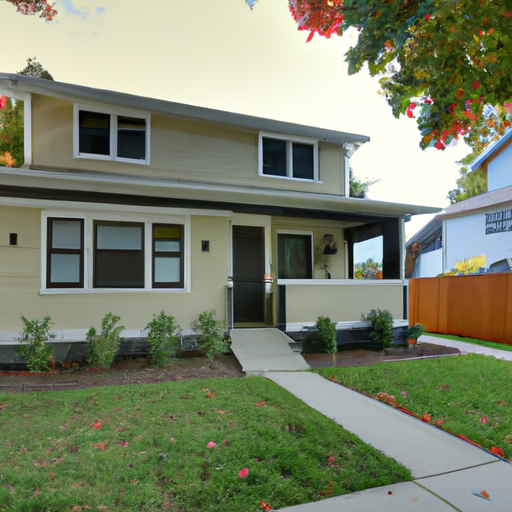

In [178]:
from IPython.display import Image 

import base64
from io import StringIO, BytesIO
from PIL import Image
# base64.decodebytes(bytes(response.data[0].b64_json))


img = Image.open(BytesIO(
    base64.b64decode(response.data[0].b64_json.encode('utf-8'))
))

img.save('my-image.jpeg')
display(img)


In [172]:
from transformers import CLIPModel, CLIPProcessor
MODEL_ID = "openai/clip-vit-base-patch32"
device = "mps"
model = CLIPModel.from_pretrained(MODEL_ID).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_ID)

In [173]:
pixel_values = processor(images = img,return_tensors="pt")["pixel_values"].to(device)
img_emb = model.get_image_features(pixel_values=pixel_values)

In [174]:
img_emb.shape

torch.Size([1, 512])

tensor([[[[-0.3616,  0.1055,  0.3537,  ...,  0.3537,  0.0471, -0.6390],
          [-0.5952, -0.4930,  0.1347,  ...,  1.1128,  0.6749,  0.3099],
          [-0.1718, -0.3470, -0.4054,  ...,  1.3172,  0.9814,  0.7625],
          ...,
          [ 0.7041,  0.7041,  0.7187,  ...,  0.4121,  0.4121,  0.4121],
          [ 0.7187,  0.7187,  0.7333,  ...,  0.4121,  0.3975,  0.4121],
          [ 0.7187,  0.7187,  0.7187,  ...,  0.4121,  0.4121,  0.4267]],

         [[-0.3714, -0.0262,  0.1239,  ...,  0.1989, -0.0712, -0.5815],
          [-0.5215, -0.4914,  0.0789,  ...,  0.9343,  0.4991,  0.2439],
          [-0.1463, -0.2513, -0.2813,  ...,  1.1594,  0.8893,  0.7092],
          ...,
          [ 0.9643,  0.9493,  0.9643,  ...,  0.7242,  0.7242,  0.7392],
          [ 0.9493,  0.9643,  0.9643,  ...,  0.7092,  0.7092,  0.7242],
          [ 0.9493,  0.9493,  0.9493,  ...,  0.7092,  0.7092,  0.7242]],

         [[-0.3142,  0.0271,  0.1551,  ..., -0.0582, -0.3000, -0.6128],
          [-0.4137, -0.3853,  